# Bookdown Python - Visualización de datos
**Autores:** Andrés Parejo, Santiago Hurtado

# Introduccion

El mercado laboral constituye uno de los principales indicadores del desempeño económico de un país, ya que refleja la capacidad de la economía para generar empleo y absorber la fuerza de trabajo disponible. En Colombia, el seguimiento continuo de indicadores laborales permite analizar la dinámica entre la población económicamente activa, los niveles de ocupación y el desempleo, proporcionando información clave para la formulación de políticas públicas y la toma de decisiones económicas.

El presente proyecto tiene como objetivo analizar el comportamiento del mercado laboral colombiano a partir de los indicadores mensuales publicados por el Banco de la República y producidos por el Departamento Administrativo Nacional de Estadística (DANE), correspondientes al período comprendido entre enero de 2001 y diciembre de 2025. Dichos indicadores se expresan en términos porcentuales y presentan una periodicidad mensual, lo que permite estudiar la evolución temporal del mercado laboral con un alto nivel de detalle.

Las variables analizadas son las siguientes:

- **Tasa Global de Participación – 13 áreas (TGP área):** Representa la relación porcentual entre la población que hace parte de la fuerza de trabajo y la población en edad de trabajar en las principales trece áreas metropolitanas del país. Este indicador refleja la presión que ejerce la población en edad de trabajar sobre el mercado laboral en dichas áreas.

- **Tasa Global de Participación – Total Nacional (TGP nacional):** Corresponde a la relación porcentual entre la población que integra la fuerza de trabajo y la población en edad de trabajar a nivel nacional. Este indicador permite medir la participación de la población en el mercado laboral en todo el país.

- **Tasa de Desempleo – 13 áreas:** Se define como la relación porcentual entre el número de personas desocupadas y el número total de personas que integran la fuerza de trabajo en las principales trece áreas metropolitanas del país.

- **Tasa de Desempleo – Total Nacional:** Corresponde a la relación porcentual entre el número de personas desocupadas y el total de personas que conforman la fuerza de trabajo a nivel nacional.

- **Tasa de Ocupación – 13 áreas:** Es la relación porcentual entre la población ocupada y la población en edad de trabajar en las principales trece áreas metropolitanas del país. Este indicador permite observar el grado de aprovechamiento de la población en edad productiva dentro del mercado laboral.

- **Tasa de Ocupación – Total Nacional:** Representa la relación porcentual entre la población ocupada y la población en edad de trabajar a nivel nacional, permitiendo evaluar el nivel de empleo en el conjunto del país.

Dentro de este conjunto de indicadores, se selecciona como variable objetivo la tasa de desempleo total nacional, debido a que este indicador sintetiza el estado general del mercado laboral y representa el resultado del equilibrio entre la oferta y la demanda de trabajo en la economía colombiana.

A partir de esta variable, se busca responder la siguiente pregunta de investigación:

**¿Cómo ha evolucionado la tasa de desempleo en Colombia a lo largo del tiempo y qué relación presenta con otros indicadores del mercado laboral como la tasa de ocupación y la tasa global de participación?**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# EDA

El Análisis Exploratorio de Datos (EDA) se realiza con el objetivo de comprender la estructura y el comportamiento de los indicadores del mercado laboral en Colombia antes de aplicar análisis más avanzados. A través de herramientas como histogramas, diagramas de caja, gráficos de dispersión y matrices de correlación, se busca identificar la distribución de las variables, detectar valores atípicos y analizar las relaciones entre la tasa de desempleo nacional (variable objetivo) y otros indicadores como la tasa de ocupación y la tasa global de participación, permitiendo obtener una primera comprensión de la dinámica del mercado laboral en el período analizado.

- Se hace una carga de los datos:

In [3]:
MLC = pd.read_excel(
    'MLC.xlsx',
    sheet_name='Series de datos',
    parse_dates=[0]
)
MLC.rename(columns={MLC.columns[0]: 'fecha'}, inplace=True)
MLC.head()

,fecha,tasa_global_participacion_area,tasa_global_participacion_nacional,tasa_desempleo_area,tasa_desempleo_nacional,tasa_ocupacion_area,tasa_ocupacion_nacional
0,2001-01-31,70.0177,69.053538,20.7176,16.622326,55.5117,57.575237
1,2001-02-28,70.2342,68.948903,19.5518,17.434206,56.5021,56.928209
2,2001-03-31,69.1487,68.387911,19.1240,15.811933,55.9247,57.574460
3,2001-04-30,67.7233,65.224009,17.5699,14.515078,55.8244,55.756693
4,2001-05-31,68.0567,65.406094,17.7675,14.035833,55.9647,56.225804


Se realiza una inspección inicial de los datos del dataset:

In [4]:
print('Nombres de columnas:')
print(MLC.columns.tolist())

print('\nTipos de datos:')
print(MLC.dtypes)

print('\nDimensiones:')
print(MLC.shape)

print('\nResumen estadístico:')
MLC.describe()

Nombres de columnas:
['fecha', 'tasa_global_participacion_area', 'tasa_global_participacion_nacional', 'tasa_desempleo_area', 'tasa_desempleo_nacional', 'tasa_ocupacion_area', 'tasa_ocupacion_nacional']

Tipos de datos:
fecha                                 datetime64[ns]
tasa_global_participacion_area               float64
tasa_global_participacion_nacional           float64
tasa_desempleo_area                          float64
tasa_desempleo_nacional                      float64
tasa_ocupacion_area                          float64
tasa_ocupacion_nacional                      float64
dtype: object

Dimensiones:
(300, 7)

Resumen estadístico:


,fecha,tasa_global_participacion_area,tasa_global_participacion_nacional,tasa_desempleo_area,tasa_desempleo_nacional,tasa_ocupacion_area,tasa_ocupacion_nacional
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2013-07-15 18:38:24,67.759280,65.740493,12.627463,11.612474,59.217590,58.120190
min,2001-01-31 00:00:00,55.088000,53.445600,7.270000,7.020000,41.658000,42.497100
25%,2007-04-22 12:00:00,66.565228,64.086900,10.449650,9.735275,57.706275,56.840939
50%,2013-07-15 12:00:00,67.953800,66.138590,11.730200,11.192750,59.587851,58.315000
75%,2019-10-07 18:00:00,69.468850,67.482400,14.021275,12.909062,61.128426,59.960250
max,2025-12-31 00:00:00,72.147900,70.617500,25.788700,21.972000,64.609700,64.008000
std,NaN,2.224336,2.346308,3.147355,2.448868,3.097003,2.854977


Verificamos que no hayan datos faltantes ni casillas vacias:

In [5]:
print(MLC.isnull().sum())

fecha                                 0
tasa_global_participacion_area        0
tasa_global_participacion_nacional    0
tasa_desempleo_area                   0
tasa_desempleo_nacional               0
tasa_ocupacion_area                   0
tasa_ocupacion_nacional               0
dtype: int64


En efecto, no encontramos ningún NA. Esto nos facilita el trabajar con los datos que la limpieza no debe ser tan rigurosa.
Otra forma de verlo sería:

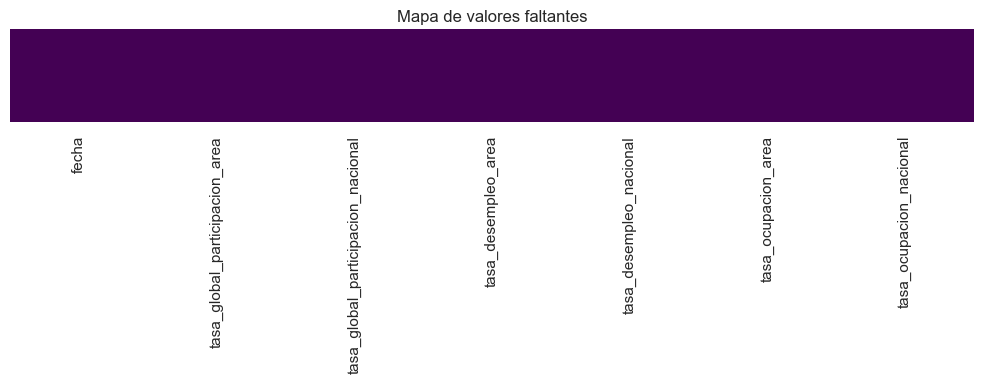

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    MLC.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=ax
)
ax.set_title('Mapa de valores faltantes')
plt.tight_layout()
plt.show()

# Analisis de la variable tasa_desempleo_nacional.

Consideremos el resumen de tasa_desempleo_nacional (objetivo):

In [7]:
col = 'tasa_desempleo_nacional'

resumen = pd.DataFrame([{
    'n':       MLC[col].count(),
    'media':   MLC[col].mean(),
    'ds':      MLC[col].std(),
    'mediana': MLC[col].median(),
    'minimo':  MLC[col].min(),
    'maximo':  MLC[col].max(),
    'Q1':      MLC[col].quantile(0.25),
    'Q3':      MLC[col].quantile(0.75),
    'IQR':     stats.iqr(MLC[col].dropna())
}])
resumen

,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,300,11.612474,2.448868,11.19275,7.02,21.972,9.735275,12.909062,3.173787


La variable tasa_desempleo_nacional fue analizada a partir de 300 observaciones. Se obtuvo una media de 11.61247 que se refleja como la tasa de desempleo nacional que se refleja como porcentaje, donde la mitad de la muestra se encuentr por debajo de 11.19275.
El minimo registrado fue de 7.02, lo que indica que en una fecha en especifico se presentó una tasa de desempleo menor a la media. Por su parte el maximo fue de 21.972, lo cual refleja una tasa de desempleo alta en una fecha en especifico.

- Con el fin de analizar la distribución de la variable tasa de desempleo nacional, se construye un histograma. Este grafico permite visualizar la concentración de los valores, identifica posibles asimetrías en la distribución, ayuda fundamentalmente para caracterizar la variable antes de estudiar sus relaciones con otros indicadores del mercado laboral.

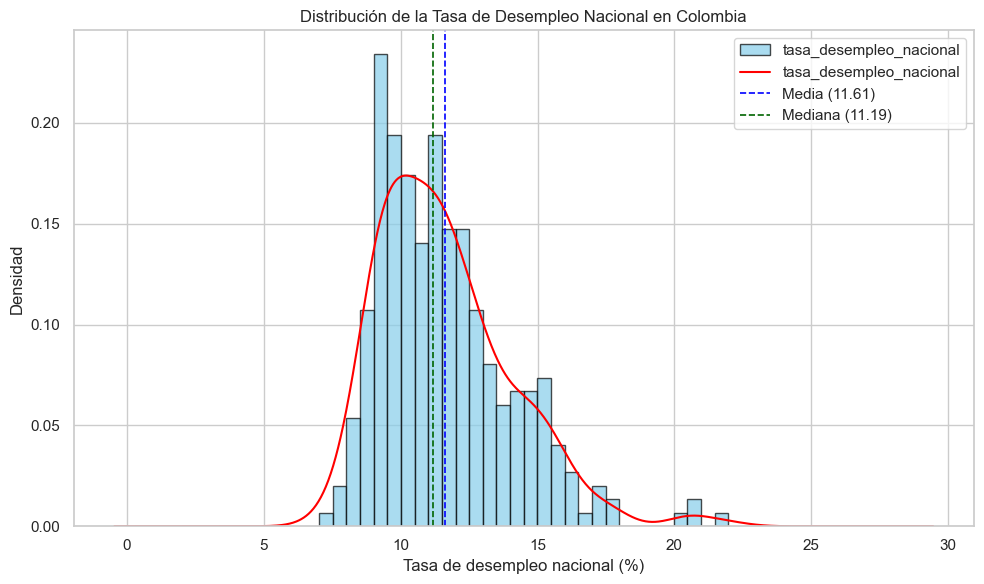

In [8]:
col = 'tasa_desempleo_nacional'
media_des   = MLC[col].mean()
mediana_des = MLC[col].median()

fig, ax = plt.subplots(figsize=(10, 6))

MLC[col].plot.hist(
    bins=30, density=True,
    color='skyblue', edgecolor='black', alpha=0.7, ax=ax
)
MLC[col].plot.kde(color='red', linewidth=1.5, ax=ax)

ax.axvline(media_des,   color='blue',      linestyle='--', linewidth=1.2, label=f'Media ({media_des:.2f})')
ax.axvline(mediana_des, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Mediana ({mediana_des:.2f})')

ax.set_title('Distribución de la Tasa de Desempleo Nacional en Colombia')
ax.set_xlabel('Tasa de desempleo nacional (%)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

El histograma presenta la distribución de frecuencias de la tasa de desempleo nacional. En el eje horizontal se ubican los intervalos de la variable (10, 15 y 20), mientras que el eje vertical muestra la frecuencia de observaciones en cada rango, con un máximo de 20.

La altura de las barras permite identificar la concentración de los datos. Si las frecuencias más altas se encuentran en los intervalos inferiores (cercanos a 10), predominan tasas de desempleo bajas. Por el contrario, si se concentran en valores superiores (cercanos a 20), predominan tasas altas. Este análisis visual facilita la comprensión del comportamiento del desempleo en el período estudiado y constituye una base descriptiva fundamental para estudios económicos y sociales.

- Para complementar el análisis del histograma, se construye un boxplot. Este tipo de visualización resume la distribución de la variable mediante sus cuantiles, analizar su dispersion de los datos a traves del rango intercuartílico y además facilita la detección de valores atípicos.- Realicemos un grafico de caja y bigote:

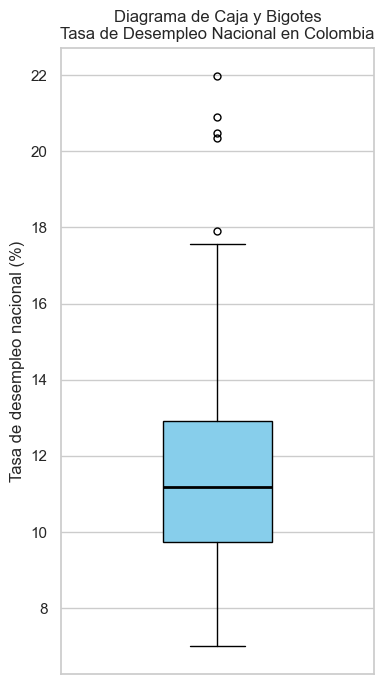

In [9]:
col = 'tasa_desempleo_nacional'

fig, ax = plt.subplots(figsize=(4, 7))
ax.boxplot(
    MLC[col].dropna(),
    vert=True,
    patch_artist=True,
    widths=0.35,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', color='red', markersize=5, linestyle='none')
)
ax.set_title('Diagrama de Caja y Bigotes\nTasa de Desempleo Nacional en Colombia')
ax.set_ylabel('Tasa de desempleo nacional (%)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

Se identifican tres puntos rojos fuera de este rango, lo que indica la presencia de valores atípicos o outliers: uno en el 20%, dos en el 15% y uno en el 10%. Estos valores se desvían del comportamiento general de la serie, posiblemente reflejando periodos con condiciones económicas excepcionales, como crisis o recuperaciones atípicas.
Se reflejan unos outliers, pero al ser el dataset economico se mantendrá por ahora.

- Una vez analizada la distribución de las variables mediante histogramas y detectados posibles valores atípicos con boxplot, se emplea el gráfico de dispersión con el fin de visualizar cada observación individualmente. Este tipo de gráfico permite confirmar la presencia de outliers, identificar patrones en los datos y complementar el análisis exploratorio previo.

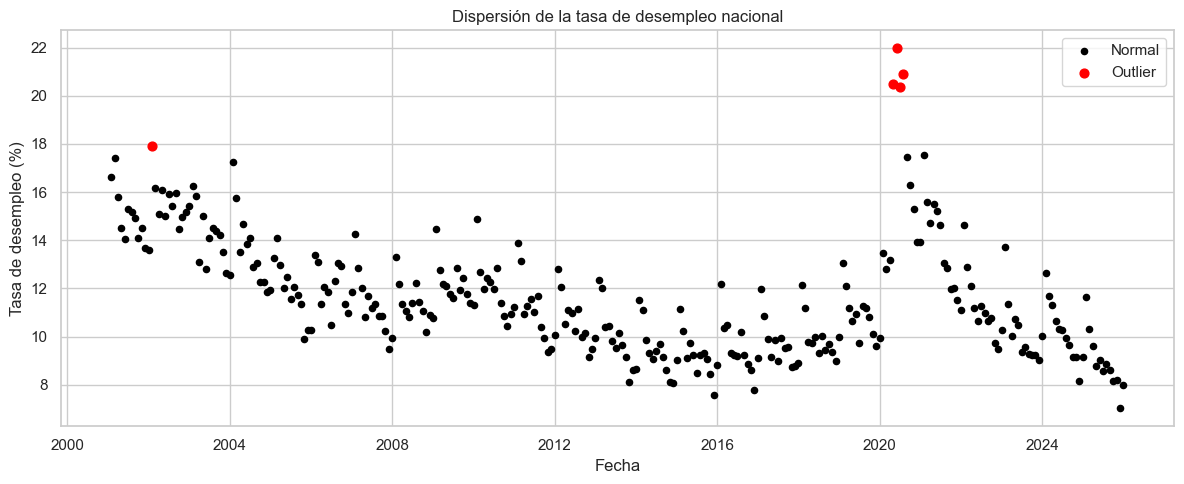

In [10]:
col = 'tasa_desempleo_nacional'

Q1      = MLC[col].quantile(0.25)
Q3      = MLC[col].quantile(0.75)
IQR_val = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR_val
lim_sup = Q3 + 1.5 * IQR_val

outliers = (MLC[col] < lim_inf) | (MLC[col] > lim_sup)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(MLC.loc[~outliers, 'fecha'], MLC.loc[~outliers, col],
           color='black', s=20, label='Normal')
ax.scatter(MLC.loc[outliers, 'fecha'],  MLC.loc[outliers, col],
           color='red', s=40, zorder=5, label='Outlier')
ax.set_title('Dispersión de la tasa de desempleo nacional')
ax.set_xlabel('Fecha')
ax.set_ylabel('Tasa de desempleo (%)')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra la evolución temporal de la tasa de desempleo nacional entre 2001 y 2025. La mayoría de los valores se concentran entre 8% y 14%, lo que indica un comportamiento relativamente estable durante gran parte del período.

No obstante, se identifican valores atípicos, especialmente alrededor del año 2020, donde el desempleo supera el 20%, reflejando un choque significativo en el mercado laboral asociado al impacto económico de la pandemia de COVID-19. Estos puntos no representan errores en los datos, sino eventos económicos extraordinarios que afectaron temporalmente la dinámica del empleo en el país.

# Analisis de las variables caracteristicas:

In [11]:
variables = [
    'tasa_global_participacion_area',
    'tasa_global_participacion_nacional',
    'tasa_desempleo_area',
    'tasa_ocupacion_area',
    'tasa_ocupacion_nacional'
]

resumen_vars = pd.DataFrame([
    {
        'variable': v,
        'n':        MLC[v].count(),
        'media':    MLC[v].mean(),
        'ds':       MLC[v].std(),
        'mediana':  MLC[v].median(),
        'minimo':   MLC[v].min(),
        'maximo':   MLC[v].max(),
        'Q1':       MLC[v].quantile(0.25),
        'Q3':       MLC[v].quantile(0.75),
        'IQR':      stats.iqr(MLC[v].dropna())
    }
    for v in variables
])
resumen_vars

,variable,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,tasa_global_participacion_area,300,67.759280,2.224336,67.953800,55.0880,72.1479,66.565228,69.468850,2.903622
1,tasa_global_participacion_nacional,300,65.740493,2.346308,66.138590,53.4456,70.6175,64.086900,67.482400,3.395500
2,tasa_desempleo_area,300,12.627463,3.147355,11.730200,7.2700,25.7887,10.449650,14.021275,3.571625
3,tasa_ocupacion_area,300,59.217590,3.097003,59.587851,41.6580,64.6097,57.706275,61.128426,3.422151
4,tasa_ocupacion_nacional,300,58.120190,2.854977,58.315000,42.4971,64.0080,56.840939,59.960250,3.119311


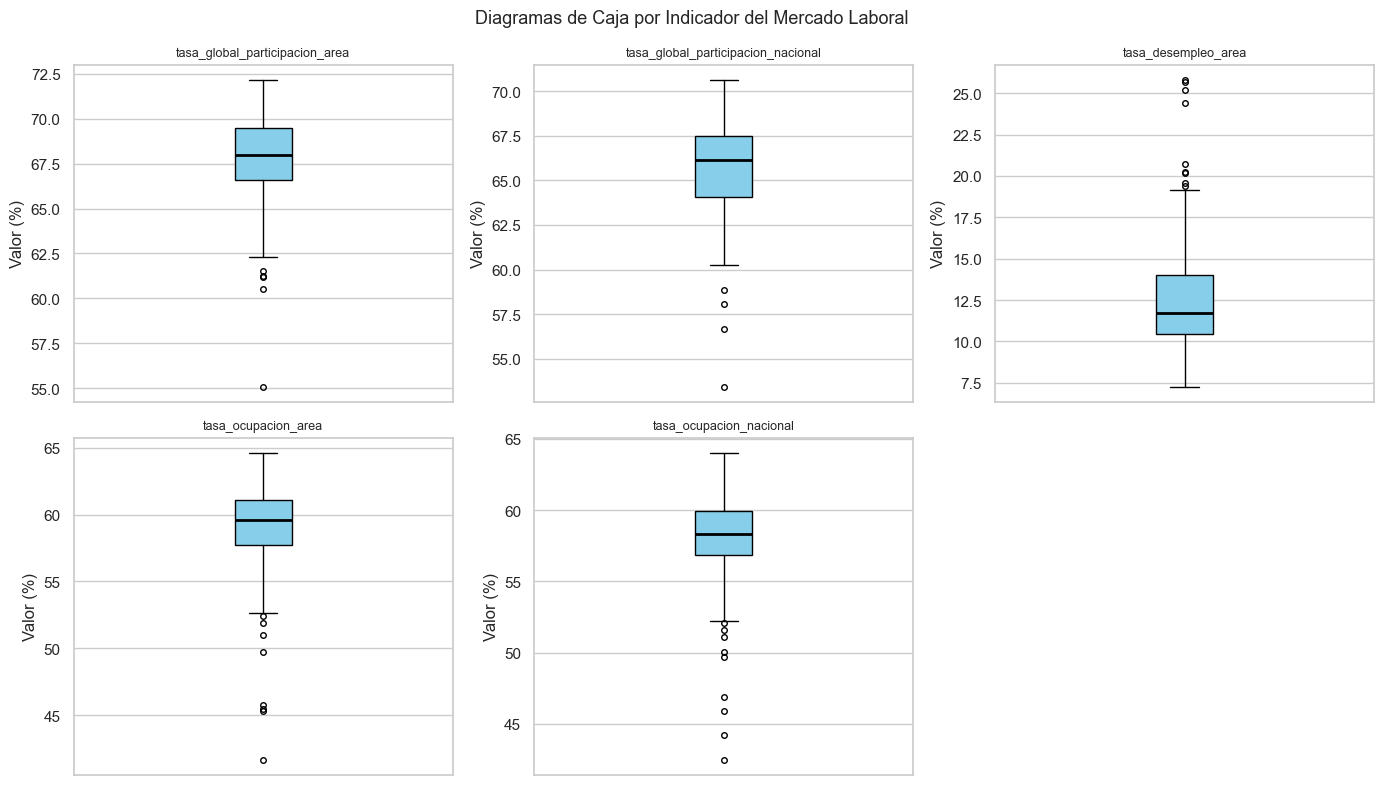

In [12]:
variables = [
    'tasa_global_participacion_area',
    'tasa_global_participacion_nacional',
    'tasa_desempleo_area',
    'tasa_ocupacion_area',
    'tasa_ocupacion_nacional'
]

MLC_long = MLC[variables].melt(var_name='variable', value_name='valor')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    data_var = MLC_long[MLC_long['variable'] == var]['valor'].dropna()
    axes[i].boxplot(
        data_var,
        patch_artist=True,
        boxprops=dict(facecolor='skyblue', color='black'),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', color='red', markersize=4)
    )
    axes[i].set_title(var, fontsize=9)
    axes[i].set_ylabel('Valor (%)')
    axes[i].set_xticks([])

axes[-1].set_visible(False)
fig.suptitle('Diagramas de Caja por Indicador del Mercado Laboral', fontsize=13)
plt.tight_layout()
plt.show()

Al analizar los boxplots presentados, observamos que la tasa de desempleo a nivel de área es el indicador con mayor variabilidad y valores más extremos, con una mediana cercana al 10% y un rango que se extiende hasta cerca del 20%, lo que refleja disparidades significativas en el desempleo local. En contraste, los indicadores de tasa de ocupación y tasa global de participación, tanto a nivel de área como nacional, presentan medianas centradas en cero y una dispersión mucho más contenida. Destaca especialmente que las versiones nacionales de estos indicadores muestran cajas más estrechas y bigotes más cortos que sus contrapartes de área, lo que sugiere que, a escala nacional, el mercado laboral tiende a ser más estable y homogéneo, mientras que a nivel local se experimentan fluctuaciones más pronunciadas y contextos laborales más diversos.

# Analisis bivariado.

Después de analizar cada variable de forma individual y de explorar algunas relaciones mediante gráficos de dispersion, resulta util complementar con una matriz de correlación que ayudará a evaluar de manera conjunta la fuerza y la dirección de la relación lineal entre los indicadores del mercado laboral. Va a permitir detectar relaciones positivas o negativas entre los indicadores, lo cuan aporta una vision mas clara de la interacción entre las variables.

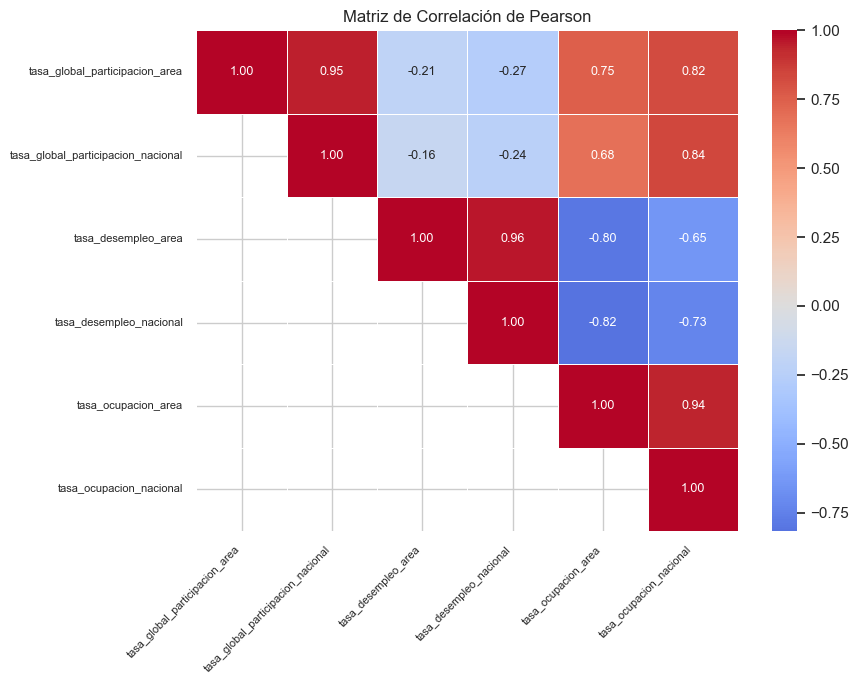

In [13]:
cols_corr = [
    'tasa_global_participacion_area',
    'tasa_global_participacion_nacional',
    'tasa_desempleo_area',
    'tasa_desempleo_nacional',
    'tasa_ocupacion_area',
    'tasa_ocupacion_nacional'
]

matriz_cor = MLC[cols_corr].corr(method='pearson')

mask = np.tril(np.ones_like(matriz_cor, dtype=bool), k=-1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    matriz_cor,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlación de Pearson')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Al examinar la matriz de correlaciones, se identifican relaciones clave en el mercado laboral. Destaca una alta correlación positiva entre las tasas de desempleo de área y nacional (0.96), así como entre las tasas de ocupación de ambos niveles (0.94), lo que indica que los comportamientos locales y nacionales tienden a moverse de manera sincronizada. Asimismo, la participación global muestra una fuerte consistencia entre el área y la nación (0.95). Por otro lado, se observa una correlación negativa significativa entre la tasa de desempleo y la tasa de ocupación (aproximadamente -0.80 en ambos niveles), lo que refleja la relación inversa esperada: a mayor desempleo, menor ocupación. Finalmente, la participación global presenta una correlación moderada a alta con la ocupación (alrededor de 0.80), sugiriendo que una mayor participación en el mercado laboral se asocia con mayores niveles de ocupación, aunque su relación con el desempleo es débil y negativa.

Tomemos las variables en el grafico de dispersion como:

- Tasa de ocupacion nacional (TON)
- Tasa de desempleo nacional (TDN)
- Tasa global de participación nacional (TGPN)
- Tasa de desempleo area (TDA)

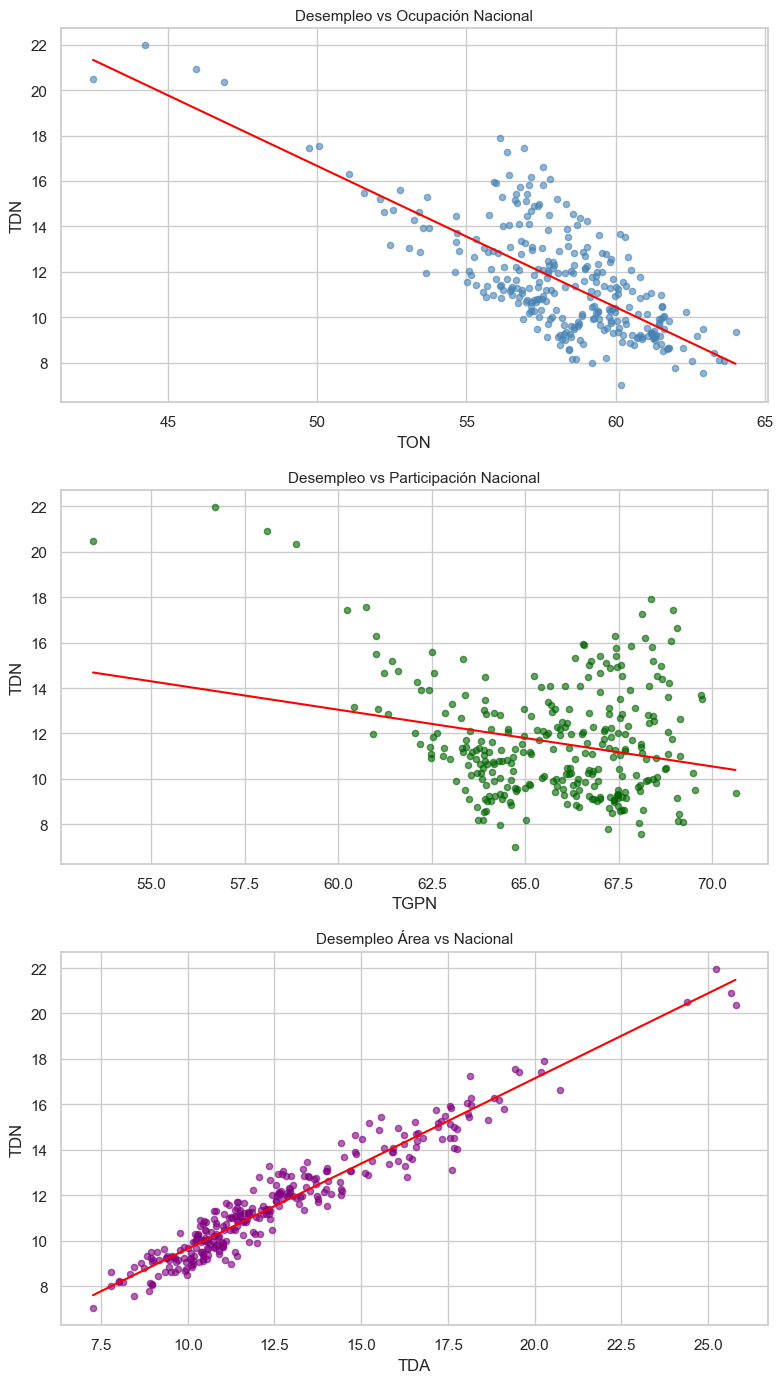

In [14]:
pares = [
    ('tasa_ocupacion_nacional',           'tasa_desempleo_nacional', 'steelblue', 'Desempleo vs Ocupación Nacional',     'TON',  'TDN'),
    ('tasa_global_participacion_nacional', 'tasa_desempleo_nacional', 'darkgreen', 'Desempleo vs Participación Nacional', 'TGPN', 'TDN'),
    ('tasa_desempleo_area',                'tasa_desempleo_nacional', 'purple',    'Desempleo Área vs Nacional',          'TDA',  'TDN'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 14))

for ax, (x_col, y_col, color, title, xlabel, ylabel) in zip(axes, pares):
    x = MLC[x_col].dropna()
    y = MLC[y_col].loc[x.index]
    ax.scatter(x, y, color=color, alpha=0.6, s=20)
    m, b, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

Al analizar las relaciones gráficas entre los indicadores del mercado laboral, se observan patrones claros y consistentes con la teoría económica.
En el primer gráfico, **Desempleo vs Ocupación Nacional**, se aprecia una clara relación inversa: a medida que aumenta la tasa de ocupación (TON), la tasa de desempleo nacional (TDN) tiende a disminuir, con puntos que oscilan entre aproximadamente 45% y 65% de ocupación y desempleo que va del 20% a valores cercanos a cero. En el segundo gráfico, **Desempleo vs Participación Nacional**, la relación es menos pronunciada pero también negativa: cuando la participación global (TGPN) aumenta —ubicándose entre 55% y 70%—, el desempleo tiende a reducirse, aunque con mayor dispersión. Finalmente, el gráfico **Desempleo Área vs Nacional** confirma una fuerte correlación positiva, donde los puntos se alinean casi perfectamente en una tendencia lineal ascendente, indicando que el comportamiento del desempleo a nivel local replica fielmente el comportamiento nacional.

- Dado que los datos corresponden a observaciones mensuales a lo largo del tiempo, es importante analizar el comportamiento de la variable objetivo desde una perspectiva temporal. Un gráfico de evolución temporal permite visualizar tendencias, cambios estructurales y posibles periodos de incremento o disminución del desempleo a lo largo del período de estudio.
Vamos a analizar la variable objetivo respecto a la ocupación donde se refleja:

**1. Cuando ocupación sube → desempleo baja.**

**2. Comportamiento inverso del mercado laboral.**

In [ ]:
MLC_temp = MLC[['fecha', 'tasa_desempleo_nacional', 'tasa_ocupacion_nacional']].copy()
MLC_temp = MLC_temp.melt(id_vars='fecha', var_name='variable', value_name='valor')

colores = {
    'tasa_desempleo_nacional': 'steelblue',
    'tasa_ocupacion_nacional': 'red'
}

fig, ax = plt.subplots(figsize=(13, 5))
for var, grupo in MLC_temp.groupby('variable'):
    ax.plot(grupo['fecha'], grupo['valor'],
            label=var, color=colores[var], linewidth=1.4)

ax.set_title('Evolución Temporal: Desempleo vs Ocupación Nacional')
ax.set_xlabel('Fecha')
ax.set_ylabel('Tasa (%)')
ax.legend(title='Indicador', fontsize=9)
plt.tight_layout()
plt.show()

Al observar la evolución temporal del mercado laboral nacional entre los años 2000 y 2025, se identifican dinámicas inversas y claramente definidas entre el desempleo y la ocupación. La tasa de desempleo nacional (línea azul) muestra picos pronunciados en periodos de crisis especialmente alrededor de 2010 y nuevamente cerca de 2020, coincidiendo con caídas simultáneas en la tasa de ocupación nacional (línea roja), lo que refleja la sensibilidad del empleo ante choques económicos. En contraste, en los periodos de recuperación, la ocupación aumenta mientras el desempleo desciende, manteniendo consistentemente la relación inversa esperada entre ambos indicadores. Esta gráfica valida visualmente la correlación negativa observada en análisis anteriores y permite identificar con claridad los momentos de mayor tensión en el mercado laboral a lo largo de las últimas dos décadas.

# Conclusiones.

A partir del análisis exploratorio de los indicadores del mercado laboral en Colombia para el período 2001–2025, se observa que la tasa de desempleo nacional presenta un comportamiento relativamente estable durante gran parte del tiempo, con valores que se concentran principalmente entre el 8% y el 14%. Sin embargo, el análisis temporal permite identificar episodios de alta volatilidad asociados a choques económicos importantes. En particular, alrededor del año 2020 se evidencia un incremento considerable del desempleo, superando el 20%, lo cual refleja el fuerte impacto que tuvo la pandemia de COVID-19 sobre la actividad económica y el mercado laboral del país.

El análisis de la distribución de la variable objetivo mediante histogramas y diagramas de caja permitió comprender su comportamiento estadístico, evidenciando una dispersión moderada y la presencia de algunos valores atípicos. Estos valores no corresponden a errores en los datos, sino a periodos extraordinarios en la economía colombiana. Por esta razón, se decidió conservarlos dentro del análisis, ya que aportan información relevante sobre la dinámica real del mercado laboral.

Por otro lado, el análisis de las variables caracteristicas mostró que los indicadores de participación y ocupación presentan una variabilidad relativamente menor en comparación con las tasas de desempleo. Esto sugiere que, aunque el nivel de participación y ocupación de la población tiende a mantenerse dentro de ciertos rangos estables, el desempleo puede experimentar fluctuaciones más pronunciadas ante cambios en el contexto económico.

El análisis bivariado permitió identificar relaciones claras entre los indicadores del mercado laboral. En particular, se observó una fuerte relación negativa entre la tasa de desempleo y la tasa de ocupación, lo cual coincide con la lógica económica: a medida que aumenta el número de personas ocupadas, la proporción de personas desempleadas tiende a disminuir. Asimismo, la matriz de correlación evidenció una alta correspondencia entre las tasas calculadas para las principales áreas metropolitanas y las tasas a nivel nacional, indicando que los comportamientos regionales están estrechamente vinculados con la dinámica del mercado laboral del país en su conjunto.

Los gráficos de dispersión también permitieron visualizar estas relaciones de forma clara, confirmando la relación inversa entre desempleo y ocupación, así como la fuerte relación positiva entre las tasas de desempleo de área y nacional. Estos resultados sugieren que el comportamiento del desempleo en las principales áreas urbanas constituye un buen indicador del comportamiento general del mercado laboral colombiano.

En conjunto, el análisis exploratorio permitió comprender la estructura del conjunto de datos, identificar patrones relevantes, detectar valores atípicos y analizar las relaciones existentes entre los principales indicadores laborales.